# Rule-Based Sentiment Analyser: Product Reviews
**AIE580S / DSE580S, Topic 7**, Cape Peninsula University of Technology

Group: Lakhikhaya Mpumlwana (220204594), Boka Winston Mokoena (221203052), Sibabalwe Ngadana (220193894)

**Notebook roadmap**
1. Setup and load data
2. Data quality checks
3. Label creation and cleaning
4. Exploratory analysis
5. Rule-based analyser (VADER, three versions) and live demo
6. Evaluation
7. Error analysis

**Setup:** run the first code cell below. It installs everything the notebook needs (`pandas numpy matplotlib seaborn nltk vaderSentiment textblob scikit-learn`), so the notebook works in Google Colab and in Jupyter. Keep `amazon_reviews.csv` in the same folder as this notebook (in Colab, upload it with the folder icon on the left). Then choose **Run all**. See `README.md` for details.

## 1. Setup and load data

In [ ]:
# Install dependencies (works in Google Colab and Jupyter). Safe to re-run.
%pip install -q pandas numpy matplotlib seaborn nltk vaderSentiment textblob scikit-learn

In [1]:
import re
import pandas as pd
import numpy as np
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

pd.set_option('display.max_colwidth', 120)
DATA_PATH = 'amazon_reviews.csv'
import os
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"'{DATA_PATH}' not found. Put amazon_reviews.csv in the same folder as this notebook "
                            "(in Google Colab: click the folder icon on the left and upload it), then run again.")
raw = pd.read_csv(DATA_PATH)
print('Shape (rows, columns):', raw.shape)
raw.head()

Shape (rows, columns): (4915, 12)


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a ...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for the higher capacity. I think its made a bit cheesier than the earlie...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. bran 64gb card and if went south after 3 months.This one has held up pre...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit, in a orange envelope, english version not asian like the picture sho...",2013-07-13,513,0,0,0,0,0.0,0.0


In [2]:
print(raw.dtypes)
print('\nDate range:', raw['reviewTime'].min(), 'to', raw['reviewTime'].max())

Unnamed: 0                int64
reviewerName                str
overall                 float64
reviewText                  str
reviewTime                  str
day_diff                  int64
helpful_yes               int64
helpful_no                int64
total_vote                int64
score_pos_neg_diff        int64
score_average_rating    float64
wilson_lower_bound      float64
dtype: object

Date range: 2012-01-09 to 2014-12-07


**Dataset description.** Amazon product reviews (source: GitHub repo `AnayDubey/Amazon-Product-Reviews-Sentiment-Analysis`). The columns we use are:
- `reviewText`: the review text (the **input** to the analyser)
- `overall`: 1–5 star rating (used to derive the **ground-truth** label)

The other columns (helpfulness votes, Wilson score, etc.) are metadata and are not used for scoring.

## 2. Data quality checks

In [3]:
# Missing / null values
missing = raw.isna().sum().to_frame('missing')
missing['percent'] = (missing['missing'] / len(raw) * 100).round(2)
missing

,missing,percent
Unnamed: 0,0,0.00
reviewerName,1,0.02
overall,0,0.00
reviewText,1,0.02
reviewTime,0,0.00
day_diff,0,0.00
helpful_yes,0,0.00
helpful_no,0,0.00
total_vote,0,0.00
score_pos_neg_diff,0,0.00


In [4]:
# Duplicates
print('Fully duplicated rows      :', raw.duplicated().sum())
print('Duplicated review texts    :', raw['reviewText'].duplicated().sum())
raw[raw['reviewText'].duplicated(keep=False) & raw['reviewText'].notna()].sort_values('reviewText')[['reviewerName','overall','reviewText']]

Fully duplicated rows      : 0
Duplicated review texts    : 2


,reviewerName,overall,reviewText
0,NaN,4.0,No issues.
3638,pinecanyon6,5.0,No issues.
309,Amazon Customer,5.0,"Works fine my Virgin Mobile HTC EVO V. The phone didn't recognize it at first, but after formatting it's all good."
913,Chaulin,4.0,"Works fine my Virgin Mobile HTC EVO V. The phone didn't recognize it at first, but after formatting it's all good."


In [5]:
# Outliers in review length (IQR rule) and rating validity
raw['word_count'] = raw['reviewText'].fillna('').str.split().str.len()
q1, q3 = raw['word_count'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(raw['word_count'].describe().round(1))
print(f'\nIQR upper fence: {upper:.0f} words')
print('Reviews above fence :', (raw['word_count'] > upper).sum())
print('Very short (<=2 words):', (raw['word_count'] <= 2).sum())
print('Invalid ratings (not 1-5):', (~raw['overall'].isin([1,2,3,4,5])).sum())

count    4915.0
mean       50.4
std        59.1
min         0.0
25%        23.0
50%        33.0
75%        55.0
max      1554.0
Name: word_count, dtype: float64

IQR upper fence: 103 words
Reviews above fence : 452
Very short (<=2 words): 17
Invalid ratings (not 1-5): 0


**Findings.** Very few missing values and duplicates. Review length is right-skewed, and a number of long reviews exceed the IQR fence. We **keep** these outliers: long reviews are genuine customer feedback, not errors, and a rule-based scorer handles any length. Empty or missing review text is removed because it cannot be scored.

## 3. Label creation and cleaning

**Ground-truth labels** are derived from the star rating (a standard convention for review sentiment):

| Stars | Label |
|---|---|
| 1–2 | negative |
| 3 | neutral |
| 4–5 | positive |

In [6]:
def rating_to_label(r):
    if r <= 2: return 'negative'
    if r == 3: return 'neutral'
    return 'positive'

df = raw.copy()
df['label'] = df['overall'].apply(rating_to_label)
print(df['label'].value_counts())
print((df['label'].value_counts(normalize=True) * 100).round(1))

label
positive    4449
negative     324
neutral      142
Name: count, dtype: int64
label
positive    90.5
negative     6.6
neutral      2.9
Name: proportion, dtype: float64


In [7]:
# Step 1: remove rows we cannot score, and duplicates
n0 = len(df)
df = df.dropna(subset=['reviewText'])
df = df[df['reviewText'].str.strip() != '']
n1 = len(df)
df = df.drop_duplicates(subset='reviewText', keep='first').reset_index(drop=True)
print(f'Start: {n0} | after dropping null/empty: {n1} | after dropping duplicates: {len(df)}')

Start: 4915 | after dropping null/empty: 4914 | after dropping duplicates: 4912


**Cleaning pipeline.** We keep two versions of the text:
- `raw_text`: untouched. VADER relies on punctuation (`!`), CAPS and negations, so it must score the original text.
- `clean_text` / `tokens`: lowercased, URLs/HTML/digits/punctuation removed, tokenized, stopwords removed. Used for word-frequency analysis and for demonstrating NLP preprocessing.

**Important:** NLTK's stopword list contains negations (*not, no, never, don't …*). Removing them would flip meaning, so we **keep** them.

In [8]:
NEGATIONS = {'no','nor','not','never','neither','none','nothing','nobody','cannot'}
base_stop = set(stopwords.words('english'))
# drop every negation form (not, no, nor, don't, didn't, isn't, ...) from the stopword list
STOP = {w for w in base_stop if w not in NEGATIONS and "n't" not in w and not w.endswith('nt')}
STOP -= {'don','didn','doesn','isn','wasn','weren','aren','couldn','shouldn','wouldn','hasn','haven','hadn','mustn','needn','shan','won','ain','mightn'}
print('Stopwords used:', len(STOP), '(NLTK default:', len(base_stop), ')')

def expand_contractions(t):
    t = t.replace('\u2019', "'")
    t = re.sub(r"\bcan't\b", 'cannot', t)
    t = re.sub(r"\bwon't\b", 'will not', t)
    t = re.sub(r"n't\b", ' not', t)
    return t

def clean_text(t):
    t = t.lower()
    t = re.sub(r'<.*?>', ' ', t)            # HTML tags
    t = re.sub(r'http\S+|www\.\S+', ' ', t)   # URLs
    t = expand_contractions(t)
    t = re.sub(r'[^a-z\s]', ' ', t)          # punctuation, digits, symbols
    return re.sub(r'\s+', ' ', t).strip()

def tokenize(t):
    return [w for w in word_tokenize(t) if w not in STOP and len(w) > 1]

df['raw_text'] = df['reviewText']
df['clean_text'] = df['raw_text'].apply(clean_text)
df['tokens'] = df['clean_text'].apply(tokenize)
df['n_tokens'] = df['tokens'].apply(len)
df['word_count'] = df['raw_text'].str.split().str.len()

# Before / after illustration
for i in [0, 5, 12]:
    print('RAW   :', df.loc[i, 'raw_text'][:160])
    print('CLEAN :', df.loc[i, 'clean_text'][:160])
    print('TOKENS:', df.loc[i, 'tokens'][:15], '\n')

Stopwords used: 158 (NLTK default: 198 )


RAW   : No issues.
CLEAN : no issues
TOKENS: ['no', 'issues'] 

RAW   : It's mini storage.  It doesn't do anything else and it's not supposed to.  I purchased it to add additional storage to my Microsoft Surface Pro tablet which onl
CLEAN : it s mini storage it does not do anything else and it s not supposed to i purchased it to add additional storage to my microsoft surface pro tablet which only c
TOKENS: ['mini', 'storage', 'not', 'anything', 'else', 'not', 'supposed', 'purchased', 'add', 'additional', 'storage', 'microsoft', 'surface', 'pro', 'tablet'] 

RAW   : THE NAME OF ITSELF SPEAKS OUT. GO SANDISK GO!
CLEAN : the name of itself speaks out go sandisk go
TOKENS: ['name', 'speaks', 'go', 'sandisk', 'go'] 



In [9]:
# Reviews that became empty after cleaning (e.g. emoji-only / punctuation-only)
empty_tok = (df['n_tokens'] == 0).sum()
print('Reviews with zero tokens after cleaning:', empty_tok)
print('Final dataset:', df.shape)
df[['raw_text','clean_text','tokens','n_tokens','word_count','overall','label']].head()

Reviews with zero tokens after cleaning: 0
Final dataset: (4912, 18)


,raw_text,clean_text,tokens,n_tokens,word_count,overall,label
0,No issues.,no issues,"[no, issues]",2,2,4.0,positive
1,"Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a ...",purchased this for my device it worked as advertised you can never have too much phone memory since i download a lot...,"[purchased, device, worked, advertised, never, much, phone, memory, since, download, lot, stuff, no, brainer]",14,31,5.0,positive
2,it works as expected. I should have sprung for the higher capacity. I think its made a bit cheesier than the earlie...,it works as expected i should have sprung for the higher capacity i think its made a bit cheesier than the earlier v...,"[works, expected, sprung, higher, capacity, think, made, bit, cheesier, earlier, versions, paint, looks, not, clean]",15,31,4.0,positive
3,This think has worked out great.Had a diff. bran 64gb card and if went south after 3 months.This one has held up pre...,this think has worked out great had a diff bran gb card and if went south after months this one has held up pretty w...,"[think, worked, great, diff, bran, gb, card, went, south, months, one, held, pretty, well, since, note, update, mont...",28,66,5.0,positive
4,"Bought it with Retail Packaging, arrived legit, in a orange envelope, english version not asian like the picture sho...",bought it with retail packaging arrived legit in a orange envelope english version not asian like the picture shows ...,"[bought, retail, packaging, arrived, legit, orange, envelope, english, version, not, asian, like, picture, shows, ar...",34,52,5.0,positive


In [10]:
# Save the cleaned dataset for the next stages
df[['raw_text','clean_text','n_tokens','word_count','overall','label']].to_csv('amazon_reviews_clean.csv', index=False)
print('Saved amazon_reviews_clean.csv')

Saved amazon_reviews_clean.csv


## 4. Exploratory data analysis (EDA)
Goal: understand the data *before* building the analyser. Each graph below is followed by what it tells us and why it matters for a rule-based approach.

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid')
ORDER = ['negative', 'neutral', 'positive']
PAL = {'negative': '#d9534f', 'neutral': '#f0ad4e', 'positive': '#5cb85c'}

### 4.1 Sentiment (class) distribution

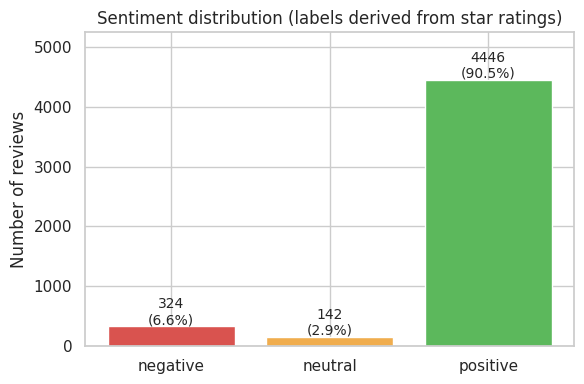

In [12]:
counts = df['label'].value_counts().reindex(ORDER)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[PAL[l] for l in counts.index])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 40, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Sentiment distribution (labels derived from star ratings)')
ax.set_ylabel('Number of reviews'); ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.savefig('figures/01_sentiment_distribution.png', dpi=150); plt.show()

**What it shows:** the data is heavily **imbalanced**. About 9 in 10 reviews are positive, and neutral reviews are very rare.
**Why it matters:** a tool that always answers "positive" would score ~90% accuracy while being useless. So we evaluate with **precision, recall and F1 per class (and macro-F1)**, not accuracy alone.

### 4.2 Star-rating distribution

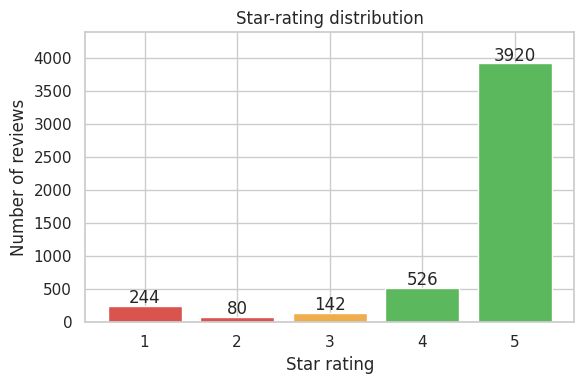

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
rc = df['overall'].astype(int).value_counts().sort_index()
colors = ['#d9534f', '#d9534f', '#f0ad4e', '#5cb85c', '#5cb85c']
ax.bar(rc.index.astype(str), rc.values, color=colors)
for i, v in enumerate(rc.values):
    ax.text(i, v + 40, str(v), ha='center')
ax.set_xlabel('Star rating'); ax.set_ylabel('Number of reviews')
ax.set_title('Star-rating distribution'); ax.set_ylim(0, rc.max() * 1.12)
plt.tight_layout(); plt.savefig('figures/02_rating_distribution.png', dpi=150); plt.show()

**What it shows:** most reviews are 5-star. 3-star reviews (our "neutral") are a small slice.
**Why it matters:** 3-star reviews are often *mixed* ("works fine but ..."), which contain both positive and negative words. These will be the hardest for a dictionary-based scorer, so we should expect lower neutral performance.

### 4.3 Review length by sentiment

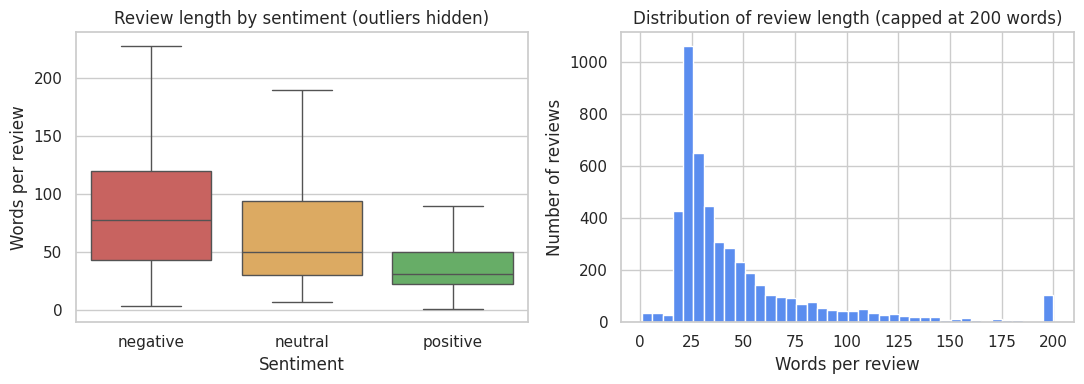

,count,mean,median
label,,,
negative,324,106.5,78.0
neutral,142,73.3,50.0
positive,4446,45.7,31.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='label', y='word_count', order=ORDER, hue='label', hue_order=ORDER, palette=PAL, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title('Review length by sentiment (outliers hidden)')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Words per review')
axes[1].hist(df['word_count'].clip(upper=200), bins=40, color='#5b8def', edgecolor='white')
axes[1].set_title('Distribution of review length (capped at 200 words)')
axes[1].set_xlabel('Words per review'); axes[1].set_ylabel('Number of reviews')
plt.tight_layout(); plt.savefig('figures/03_review_length.png', dpi=150); plt.show()

df.groupby('label')['word_count'].agg(['count', 'mean', 'median']).reindex(ORDER).round(1)

**What it shows:** the length summary table above shows whether unhappy customers write more than happy ones. Most reviews are short (a few dozen words), with a long tail of very long ones.
**Why it matters:** longer reviews contain more sentiment words, so they are more likely to have mixed signals. Very short reviews ("No issues.") give the scorer little to work with.

### 4.4 Most frequent words per class

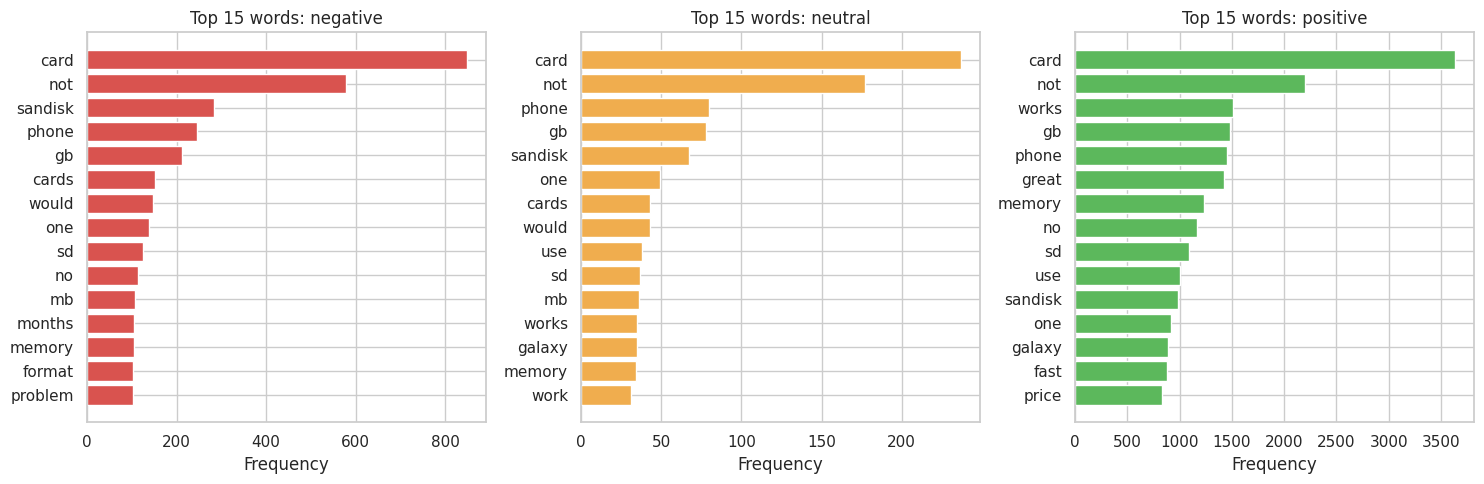

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, lab in zip(axes, ORDER):
    c = Counter(w for toks in df.loc[df['label'] == lab, 'tokens'] for w in toks)
    words, freq = zip(*c.most_common(15))
    ax.barh(words[::-1], freq[::-1], color=PAL[lab])
    ax.set_title(f'Top 15 words: {lab}')
    ax.set_xlabel('Frequency')
plt.tight_layout(); plt.savefig('figures/04_top_words_per_class.png', dpi=150); plt.show()

**What it shows:** the most common words are mostly *product words* (card, phone, memory ...) that appear in every class, so raw frequency alone does not separate the sentiments.
**Why it matters:** this is why we need a **sentiment lexicon** (words with sentiment scores) and not just word counts. The next graph looks at *distinctive* words instead.

### 4.5 Distinctive words: negative vs positive reviews

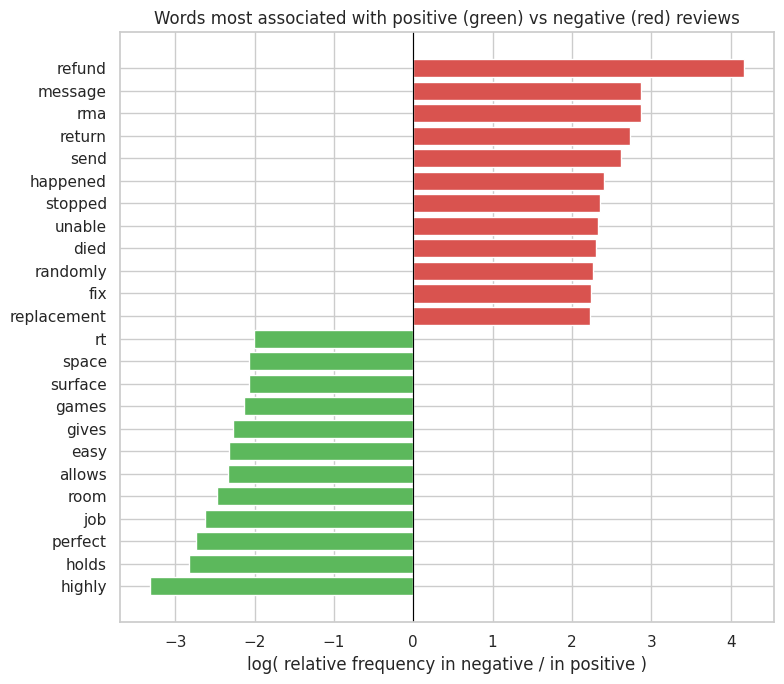

In [16]:
pos_c = Counter(w for t in df.loc[df['label'] == 'positive', 'tokens'] for w in t)
neg_c = Counter(w for t in df.loc[df['label'] == 'negative', 'tokens'] for w in t)
pos_n, neg_n = sum(pos_c.values()), sum(neg_c.values())

rows = []
for w in set(pos_c) | set(neg_c):
    if pos_c[w] + neg_c[w] >= 20:                      # ignore rare words
        pf, nf = (pos_c[w] + 1) / pos_n, (neg_c[w] + 1) / neg_n
        rows.append((w, np.log(nf / pf)))              # >0 : more common in negative
dist = pd.DataFrame(rows, columns=['word', 'log_ratio']).sort_values('log_ratio')
top = pd.concat([dist.head(12), dist.tail(12)])

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top['word'], top['log_ratio'], color=['#5cb85c' if v < 0 else '#d9534f' for v in top['log_ratio']])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Words most associated with positive (green) vs negative (red) reviews')
ax.set_xlabel('log( relative frequency in negative / in positive )')
plt.tight_layout(); plt.savefig('figures/05_distinctive_words.png', dpi=150); plt.show()

**What it shows:** words that lean strongly positive or negative (e.g. praise words on one side, failure/complaint words on the other).
**Why it matters:** this confirms that sentiment *is* carried by individual words, which is the core assumption of a lexicon-based scorer.

### 4.6 How much of the vocabulary does the VADER lexicon cover?

Words in VADER lexicon: 7506

Reviews with at least one lexicon word: 94.6%
Avg % of tokens found in lexicon:
 label
negative    13.3
neutral     13.6
positive    16.1
Name: lex_cov, dtype: float64


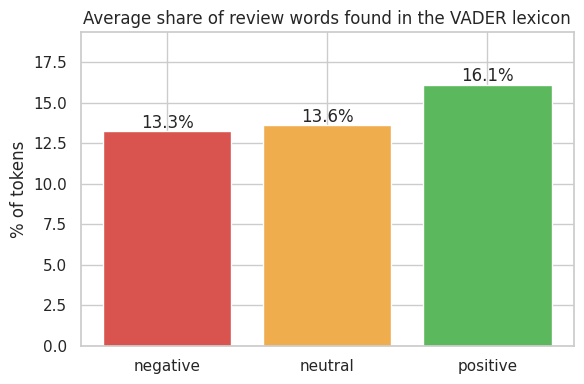

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
lexicon = SentimentIntensityAnalyzer().lexicon        # dict: word -> valence (-4 .. +4)
print('Words in VADER lexicon:', len(lexicon))

df['lex_hits'] = df['tokens'].apply(lambda t: sum(w in lexicon for w in t))
df['lex_cov'] = df['lex_hits'] / df['n_tokens'].clip(lower=1)

cov = df.groupby('label')['lex_cov'].mean().reindex(ORDER) * 100
print(f"\nReviews with at least one lexicon word: {(df['lex_hits'] > 0).mean()*100:.1f}%")
print('Avg % of tokens found in lexicon:\n', cov.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cov.index, cov.values, color=[PAL[l] for l in cov.index])
for i, v in enumerate(cov.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center')
ax.set_title('Average share of review words found in the VADER lexicon')
ax.set_ylabel('% of tokens'); ax.set_ylim(0, cov.max() * 1.2)
plt.tight_layout(); plt.savefig('figures/06_lexicon_coverage.png', dpi=150); plt.show()

**What it shows:** the share of each review's words that the dictionary recognises, and how many reviews contain at least one known sentiment word.
**Why it matters:** a rule-based tool can only score words it knows. Reviews with no lexicon words will default to neutral, and domain terms (e.g. technical words) are invisible to it. This predicts some of the errors we will analyse later.

### 4.7 EDA summary: how it helps address the problem
- **Imbalance** → evaluate with per-class precision/recall/F1 and macro-F1, not accuracy alone.
- **Mixed 3-star reviews** → expect neutral to be the hardest class.
- **Sentiment is carried by words** (distinctive-word graph) → a lexicon approach is appropriate.
- **Lexicon coverage** → shows both the strength and the blind spots of using a fixed dictionary.

## 5. The rule-based sentiment analyser
**Approach:** VADER (*Valence Aware Dictionary and sEntiment Reasoner*), a lexicon-and-rules tool. No model is trained. Every word in a dictionary has a fixed score, and a set of hand-written rules adjusts them.

We build and compare **three versions** so we can measure what each improvement is worth:

| Version | Dictionary | Thresholds |
|---|---|---|
| **A. VADER default** | built-in VADER lexicon | standard (±0.05) |
| **B. VADER + tuned thresholds** | built-in VADER lexicon | tuned on training data |
| **C. VADER + domain lexicon** | VADER + our custom review words | tuned on training data |

### 5.1 Train / test split
To keep evaluation honest, everything we tune (thresholds, custom words) uses the **training split only**. The **test split is untouched** until the evaluation section.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)

print('Train:', len(train_df), train_df['label'].value_counts().to_dict())
print('Test :', len(test_df),  test_df['label'].value_counts().to_dict())

keep = ['raw_text', 'clean_text', 'overall', 'label']
train_df[keep].to_csv('train.csv', index=False); test_df[keep].to_csv('test.csv', index=False)

Train: 3438 {'positive': 3112, 'negative': 227, 'neutral': 99}
Test : 1474 {'positive': 1334, 'negative': 97, 'neutral': 43}


### 5.2 How the rule-based scoring works
VADER scores a review in these steps:
1. **Lexicon lookup:** each word has a valence from −4 (very negative) to +4 (very positive), e.g. *great* ≈ +3.1, *terrible* ≈ −2.1. Unknown words score 0.
2. **Intensity rules:** CAPITALS, exclamation marks and boosters (*very*, *extremely*) increase the score. Dampeners (*slightly*, *kind of*) reduce it.
3. **Negation rule:** a negator (*not, never, n't*) within the 3 words before a sentiment word flips and weakens it ("not good" becomes negative).
4. **"But" rule:** sentiment after *but* is weighted more than before it ("good card, **but** it died" leans negative).
5. **Sum and normalise:** word scores are added, then squashed into a single **compound score** between −1 and +1.
6. **Thresholds (our decision rule):** compound ≥ `pos_t` → **positive**, ≤ `neg_t` → **negative**, otherwise **neutral**.

In [19]:
vader = SentimentIntensityAnalyzer()
for s in ['The card is good.', 'The card is NOT good.', 'The card is very good!!!', 'Good card, but it died.']:
    print(f"{vader.polarity_scores(s)['compound']:+.3f}  {s}")

+0.440  The card is good.
-0.341  The card is NOT good.
+0.621  The card is very good!!!
-0.606  Good card, but it died.


### 5.3 Version A: VADER with default thresholds

In [20]:
ORDER = ['negative', 'neutral', 'positive']

def to_label(c, pos_t, neg_t):
    return np.where(c >= pos_t, 'positive', np.where(c <= neg_t, 'negative', 'neutral'))

def score_all(analyser, texts):
    return np.array([analyser.polarity_scores(t)['compound'] for t in texts])

train_df['score_A'] = score_all(vader, train_df['raw_text'])
train_df['pred_A']  = to_label(train_df['score_A'], 0.05, -0.05)

pd.DataFrame({'actual': train_df['label'].value_counts(), 'predicted_A': train_df['pred_A'].value_counts()}).reindex(ORDER)

,actual,predicted_A
negative,227,428
neutral,99,237
positive,3112,2773


With the default thresholds VADER almost never says "neutral", because compound scores are rarely between −0.05 and +0.05. That is a known limitation of default thresholds, which we address next.

### 5.4 Version B: tune the thresholds (training data only)
We search a grid of positive/negative cut-offs and keep the pair with the best **macro-F1** (the average F1 across the three classes, so the rare neutral class counts as much as the common positive one).

In [21]:
def tune_thresholds(scores, y):
    best = (-1, None, None)
    grid = np.round(np.arange(0.05, 0.65, 0.05), 2)
    for p in grid:
        for n in grid:
            f = f1_score(y, to_label(scores, p, -n), labels=ORDER, average='macro', zero_division=0)
            if f > best[0]:
                best = (f, p, -n)
    return best

fA = f1_score(train_df['label'], train_df['pred_A'], labels=ORDER, average='macro', zero_division=0)
fB, posB, negB = tune_thresholds(train_df['score_A'].values, train_df['label'])
print(f'Version A (default ±0.05)   train macro-F1 = {fA:.3f}')
print(f'Version B (tuned: +{posB}, {negB}) train macro-F1 = {fB:.3f}')

Version A (default ±0.05)   train macro-F1 = 0.459
Version B (tuned: +0.05, -0.4) train macro-F1 = 0.475


### 5.5 Version C: add a small domain lexicon
The EDA showed that many complaint words (*refund, rma, replacement, unable*) are **missing** from VADER. We list the words most associated with negative or positive reviews in the **training split** that VADER does not know, then add the ones that clearly carry sentiment.

In [22]:
from collections import Counter
lex = vader.lexicon
P = Counter(w for t in train_df.loc[train_df['label'] == 'positive', 'clean_text'] for w in t.split())
N = Counter(w for t in train_df.loc[train_df['label'] == 'negative', 'clean_text'] for w in t.split())
pn, nn = sum(P.values()), sum(N.values())
rows = [(w, np.log(((N[w] + 1) / nn) / ((P[w] + 1) / pn)), N[w], P[w])
        for w in set(P) | set(N) if N[w] + P[w] >= 8 and w not in lex and len(w) > 2]
cand = pd.DataFrame(rows, columns=['word', 'log_ratio', 'in_negative', 'in_positive']).sort_values('log_ratio')
print('Top negative-leaning words missing from VADER (train only):')
display(cand.tail(15).iloc[::-1].round(2).reset_index(drop=True))
print('Top positive-leaning words missing from VADER (train only):')
display(cand.head(10).round(2).reset_index(drop=True))

Top negative-leaning words missing from VADER (train only):


,word,log_ratio,in_negative,in_positive
0,window,4.08,9,0
1,refund,3.72,13,1
2,send,3.51,16,2
3,restarted,3.39,9,1
4,rma,3.08,10,2
5,december,2.98,9,2
6,lexar,2.88,8,2
7,unmount,2.88,8,2
8,return,2.72,35,13
9,message,2.69,14,5


Top positive-leaning words missing from VADER (train only):


,word,log_ratio,in_negative,in_positive
0,highly,-3.03,0,121
1,holds,-2.49,0,70
2,job,-2.30,0,58
3,room,-2.12,1,97
4,allows,-2.05,0,45
5,performance,-2.01,1,87
6,transfers,-2.01,0,43
7,she,-1.98,0,42
8,anyone,-1.95,1,82
9,gives,-1.94,0,40


**Manual selection:** from those lists we keep only words that *clearly express* sentiment about a product. We skip brand names (*lexar, transcend*), dates (*december*) and ambiguous words (*gone, fixed*). The scores are our own judgement on VADER's −4…+4 scale, set conservatively below VADER's strongest words.

In [23]:
CUSTOM_LEXICON = {
    # negative: returns, failures, complaints missing from VADER
    'refund': -1.5, 'rma': -1.5, 'replacement': -1.0, 'return': -1.0, 'returned': -1.2, 'returning': -1.0,
    'unable': -1.5, 'unreadable': -2.0, 'unmount': -1.2, 'unmounting': -1.2,
    'randomly': -1.0, 'unexpectedly': -1.0, 'suddenly': -0.8, 'fix': -0.8,
    # positive: everyday praise missing from VADER
    'works': 0.8, 'fast': 1.2, 'plenty': 0.8,
}
vader_c = SentimentIntensityAnalyzer()
vader_c.lexicon.update(CUSTOM_LEXICON)
print(len(CUSTOM_LEXICON), 'custom words added. Lexicon size:', len(vader.lexicon), '→', len(vader_c.lexicon))

train_df['score_C'] = score_all(vader_c, train_df['raw_text'])
fC, posC, negC = tune_thresholds(train_df['score_C'].values, train_df['label'])
print(f'Version C (tuned: +{posC}, {negC}) train macro-F1 = {fC:.3f}')

17 custom words added. Lexicon size: 7506 → 7523


Version C (tuned: +0.05, -0.5) train macro-F1 = 0.505


### 5.6 Training-set comparison (used only to choose the final version)

In [24]:
summary = pd.DataFrame({
    'Version': ['A. VADER default', 'B. VADER + tuned thresholds', 'C. VADER + domain lexicon'],
    'pos threshold': [0.05, posB, posC], 'neg threshold': [-0.05, negB, negC],
    'train macro-F1': [fA, fB, fC]}).round(3)
summary

,Version,pos threshold,neg threshold,train macro-F1
0,A. VADER default,0.05,-0.05,0.459
1,B. VADER + tuned thresholds,0.05,-0.40,0.475
2,C. VADER + domain lexicon,0.05,-0.50,0.505


These are **training** scores, used only to set the thresholds. The fair comparison on unseen **test** data comes in the evaluation section.

### 5.7 The analyser function (try it on any review)

In [25]:
def analyse(text, analyser=vader_c, pos_t=posC, neg_t=negC, show=True):
    '''Return (label, compound) and, if show=True, print which words drove the score.'''
    comp = analyser.polarity_scores(text)['compound']
    label = str(to_label(np.array([comp]), pos_t, neg_t)[0])
    if show:
        words = re.findall(r"[a-zA-Z']+", text.lower())
        hits = [(w, analyser.lexicon[w]) for w in words if w in analyser.lexicon]
        print(f'Review   : {text}')
        print(f'Sentiment: {label.upper()}   (compound = {comp:+.3f})')
        print('Words    :', ', '.join(f'{w} ({v:+.1f})' for w, v in hits) if hits else 'no sentiment words found')
        print()
    return label, comp

demo = ['Great card, works perfectly and very fast!',
        'Terrible. It died after a week and I had to ask for a refund.',
        'It is okay, nothing special.',
        'This card is not good at all.',
        'Good card, but it stopped working after two days.',
        'Oh great, another card that died in a week. Just what I needed.']   # sarcasm
for s in demo:
    analyse(s)

Review   : Great card, works perfectly and very fast!
Sentiment: POSITIVE   (compound = +0.917)
Words    : great (+3.1), works (+0.8), perfectly (+3.2), fast (+1.2)

Review   : Terrible. It died after a week and I had to ask for a refund.
Sentiment: NEGATIVE   (compound = -0.848)
Words    : terrible (-2.1), died (-2.6), refund (-1.5)

Review   : It is okay, nothing special.
Sentiment: NEUTRAL   (compound = -0.092)
Words    : okay (+0.9), special (+1.7)

Review   : This card is not good at all.
Sentiment: NEUTRAL   (compound = -0.341)
Words    : good (+1.9)

Review   : Good card, but it stopped working after two days.
Sentiment: NEUTRAL   (compound = -0.103)
Words    : good (+1.9), stopped (-0.9)

Review   : Oh great, another card that died in a week. Just what I needed.
Sentiment: POSITIVE   (compound = +0.128)
Words    : great (+3.1), died (-2.6)



Notice the last example: **sarcasm** fools a lexicon scorer because "great" and "needed" look positive. We keep this as a documented limitation (Part F).

### 5.8 Interactive demo (for the demo video)
Set `RUN_INTERACTIVE = True` in the cell below and run it. Type any review and press Enter; type `quit` to stop.
It is `False` by default so that **Run all** does not pause waiting for input.

In [ ]:
RUN_INTERACTIVE = False   # <-- change to True for the live demo (works in Jupyter and Google Colab)

if RUN_INTERACTIVE:
    while True:
        text = input('Enter a review (or "quit"): ')
        if text.strip().lower() == 'quit':
            break
        analyse(text)

### 5.9 Score both splits with all three versions
Predictions are stored now; the **test** metrics are computed in the next section.

In [27]:
train_df['pred_B'] = to_label(train_df['score_A'], posB, negB)
train_df['pred_C'] = to_label(train_df['score_C'], posC, negC)

test_df['score_A'] = score_all(vader,   test_df['raw_text'])
test_df['score_C'] = score_all(vader_c, test_df['raw_text'])
test_df['pred_A'] = to_label(test_df['score_A'], 0.05, -0.05)
test_df['pred_B'] = to_label(test_df['score_A'], posB, negB)
test_df['pred_C'] = to_label(test_df['score_C'], posC, negC)

print('Predicted label counts on the test split:')
pd.DataFrame({'actual': test_df['label'].value_counts(), 'A': test_df['pred_A'].value_counts(),
              'B': test_df['pred_B'].value_counts(), 'C': test_df['pred_C'].value_counts()}).reindex(ORDER).fillna(0).astype(int)

Predicted label counts on the test split:


,actual,A,B,C
negative,97,182,98,83
neutral,43,115,199,184
positive,1334,1177,1177,1207


## 6. Testing and performance evaluation
All numbers in this section use the **test split** (1,474 reviews) that was never used to tune anything.

**Metrics used**
- **Accuracy:** share of reviews classified correctly. Misleading here, because always saying "positive" already scores ≈ 90%.
- **Precision (per class):** of the reviews we *called* X, how many really were X.
- **Recall (per class):** of the reviews that really *are* X, how many we found.
- **F1 (per class):** the balance of precision and recall.
- **Macro-F1:** the average F1 across the three classes. It treats rare classes (negative, neutral) as equal to the common one, so it is our **main metric**.

### 6.1 Results for our three versions (plus a trivial baseline)

In [28]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

def evaluate(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=ORDER, zero_division=0)
    out = {'Accuracy': accuracy_score(y_true, y_pred), 'Macro-P': p.mean(), 'Macro-R': r.mean(), 'Macro-F1': f.mean()}
    out.update({f'F1 {l}': v for l, v in zip(ORDER, f)})
    return out

y = test_df['label']
results = {
    'Baseline: always "positive"': evaluate(y, ['positive'] * len(y)),
    'A. VADER default':            evaluate(y, test_df['pred_A']),
    'B. VADER + tuned thresholds': evaluate(y, test_df['pred_B']),
    'C. VADER + domain lexicon':   evaluate(y, test_df['pred_C']),
}
res_df = pd.DataFrame(results).T.round(3)
res_df

,Accuracy,Macro-P,Macro-R,Macro-F1,F1 negative,F1 neutral,F1 positive
"Baseline: always ""positive""",0.905,0.302,0.333,0.317,0.000,0.000,0.950
A. VADER default,0.791,0.415,0.473,0.428,0.358,0.038,0.886
B. VADER + tuned thresholds,0.786,0.460,0.466,0.448,0.400,0.058,0.886
C. VADER + domain lexicon,0.814,0.502,0.513,0.485,0.456,0.097,0.904


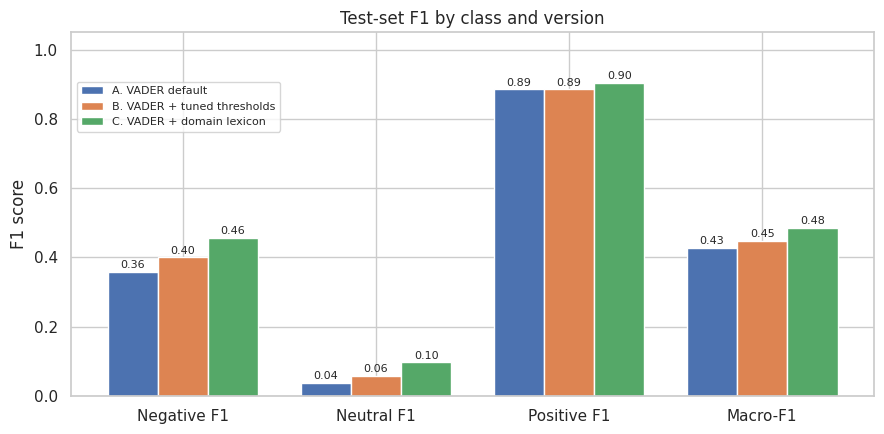

In [29]:
fig, ax = plt.subplots(figsize=(9, 4.5))
names = ['A. VADER default', 'B. VADER + tuned thresholds', 'C. VADER + domain lexicon']
cols = ['F1 negative', 'F1 neutral', 'F1 positive', 'Macro-F1']
x = np.arange(len(cols)); w = 0.26
for i, n in enumerate(names):
    vals = res_df.loc[n, cols].values.astype(float)
    bars = ax.bar(x + (i - 1) * w, vals, w, label=n)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(['Negative F1', 'Neutral F1', 'Positive F1', 'Macro-F1'])
ax.set_ylim(0, 1.05); ax.set_ylabel('F1 score'); ax.set_title('Test-set F1 by class and version')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(0.0, 0.88))
plt.tight_layout(); plt.savefig('figures/07_f1_by_version.png', dpi=150); plt.show()

**Reading the results**
- **Accuracy is misleading here.** The trivial "always positive" baseline scores **0.905 accuracy**, higher than all three of our versions (0.79 to 0.81), yet its macro-F1 is only **0.317** because it never finds a negative or neutral review. This confirms why we use macro-F1.
- **Each improvement helps.** Macro-F1 rises from **0.428 (A)** to **0.448 (B)** to **0.485 (C)**, and C is best on every class.
- **Positive reviews are handled well** (F1 ≈ 0.90), **negative moderately** (F1 0.46), and **neutral very poorly** (F1 0.10).
- **Caution:** the test set has only 97 negative and 43 neutral reviews, so gaps of a few points can partly be chance. The consistent direction across all classes is the more reliable signal.

### 6.2 Confusion matrices
Each row is the **true** class, each column the **predicted** class. Numbers show review counts and the percentage of that true class.

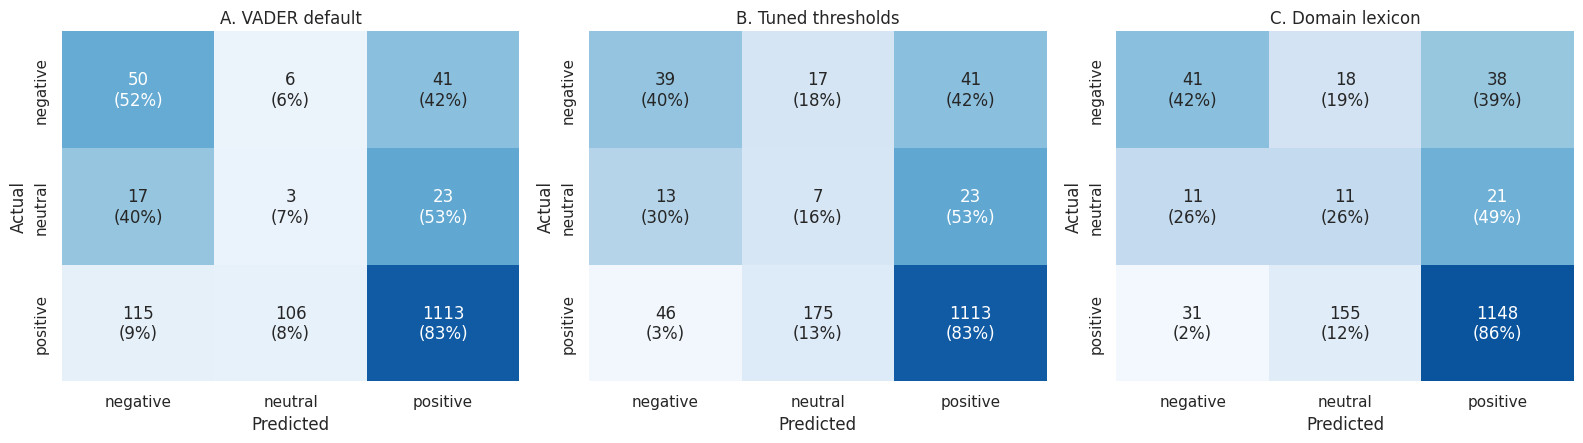

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (col, title) in zip(axes, [('pred_A', 'A. VADER default'), ('pred_B', 'B. Tuned thresholds'), ('pred_C', 'C. Domain lexicon')]):
    cm = confusion_matrix(test_df['label'], test_df[col], labels=ORDER)
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{cm[i, j]}\n({pct[i, j]:.0f}%)' for j in range(3)] for i in range(3)])
    sns.heatmap(pct, annot=annot, fmt='', cmap='Blues', cbar=False, vmin=0, vmax=100,
                xticklabels=ORDER, yticklabels=ORDER, ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('figures/08_confusion_matrices.png', dpi=150); plt.show()

**Reading the confusion matrices (Version C):** 86% of positive reviews and 42% of negative reviews are correct, but only **26% of neutral reviews**. The biggest single problem is in the bottom row: **155 genuinely positive reviews (12%) are called neutral**. Because positive reviews are so numerous, even a small share of them landing in "neutral" swamps the 43 real neutral reviews, which is why neutral *precision* is only 0.06.

### 6.3 Detailed report for our chosen version (C)
Version C was chosen because it had the best macro-F1 on the **training** data (not by looking at the test results).

In [31]:
print(classification_report(test_df['label'], test_df['pred_C'], labels=ORDER, digits=3, zero_division=0))

              precision    recall  f1-score   support

    negative      0.494     0.423     0.456        97
     neutral      0.060     0.256     0.097        43
    positive      0.951     0.861     0.904      1334

    accuracy                          0.814      1474
   macro avg      0.502     0.513     0.485      1474
weighted avg      0.895     0.814     0.851      1474



**Reading the report:** for **negative** reviews precision (0.49) and recall (0.42) are both moderate. For **neutral**, recall (0.26) is higher than precision (0.06): we catch about a quarter of true neutral reviews, but most reviews we label "neutral" are really positive.

### 6.4 Comparison with other tools (TextBlob and a plain word-count dictionary)
For each tool the thresholds are tuned on the **training split**, exactly like Versions B and C, so the comparison is fair.
- **TextBlob:** another popular rule/lexicon tool (averages word polarity from a built-in dictionary).
- **Manual word-count:** just adds up the VADER dictionary scores of every word, with **no rules** for negation, capitals, "but" and so on. This shows what VADER's rules add.

In [32]:
from textblob import TextBlob

# TextBlob
tb_score = lambda s: TextBlob(s).sentiment.polarity
train_df['score_TB'] = train_df['raw_text'].apply(tb_score)
test_df['score_TB']  = test_df['raw_text'].apply(tb_score)
_, posT, negT = tune_thresholds(train_df['score_TB'].values, train_df['label'])

# Manual word-count dictionary (no rules), squashed to the same -1..1 scale as VADER
def manual_score(text, lexicon=vader.lexicon):
    s = sum(lexicon.get(w, 0) for w in re.findall(r"[a-z']+", text.lower()))
    return s / np.sqrt(s * s + 15)
train_df['score_M'] = train_df['raw_text'].apply(manual_score)
test_df['score_M']  = test_df['raw_text'].apply(manual_score)
_, posM, negM = tune_thresholds(train_df['score_M'].values, train_df['label'])

tools = {
    'TextBlob (default ±0.05)':   to_label(test_df['score_TB'], 0.05, -0.05),
    f'TextBlob (tuned +{posT}, {negT})': to_label(test_df['score_TB'], posT, negT),
    'Word-count, no rules (tuned)': to_label(test_df['score_M'], posM, negM),
    'A. VADER default':           test_df['pred_A'],
    'B. VADER + tuned thresholds': test_df['pred_B'],
    'C. VADER + domain lexicon':  test_df['pred_C'],
}
tool_df = pd.DataFrame({k: evaluate(y, v) for k, v in tools.items()}).T.round(3)
tool_df.sort_values('Macro-F1', ascending=False)

,Accuracy,Macro-P,Macro-R,Macro-F1,F1 negative,F1 neutral,F1 positive
C. VADER + domain lexicon,0.814,0.502,0.513,0.485,0.456,0.097,0.904
B. VADER + tuned thresholds,0.786,0.460,0.466,0.448,0.400,0.058,0.886
A. VADER default,0.791,0.415,0.473,0.428,0.358,0.038,0.886
"Word-count, no rules (tuned)",0.739,0.415,0.468,0.416,0.338,0.056,0.853
"TextBlob (tuned +0.05, -0.05)",0.775,0.402,0.377,0.385,0.255,0.017,0.882
TextBlob (default ±0.05),0.775,0.402,0.377,0.385,0.255,0.017,0.882


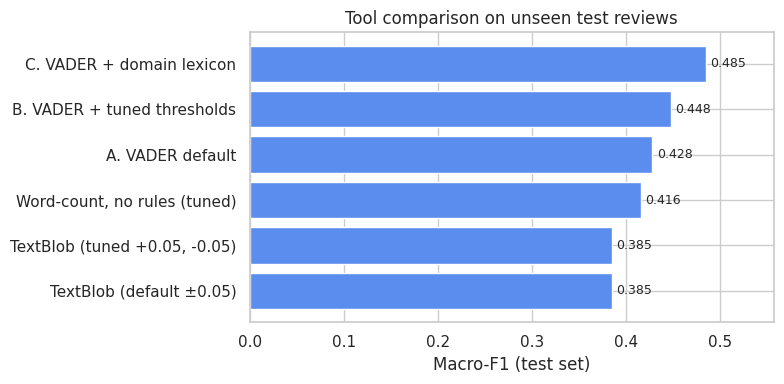

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
t = tool_df.sort_values('Macro-F1')
bars = ax.barh(t.index, t['Macro-F1'], color='#5b8def')
for b, v in zip(bars, t['Macro-F1']):
    ax.text(v + 0.005, b.get_y() + b.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0, t['Macro-F1'].max() * 1.15); ax.set_xlabel('Macro-F1 (test set)')
ax.set_title('Tool comparison on unseen test reviews')
plt.tight_layout(); plt.savefig('figures/09_tool_comparison.png', dpi=150); plt.show()

**Reading the tool comparison**
- **Version C (VADER + domain lexicon) is best** at macro-F1 0.485, ahead of plain VADER (0.428), the no-rules word-count dictionary (0.416) and TextBlob (0.385).
- **VADER's rules matter for accuracy:** the no-rules word-count version is about 5 points less accurate (0.739 vs 0.791) than default VADER. Negation, capitals and "but" handling help, though the macro-F1 gain is small (0.416 → 0.428).
- **TextBlob** does worst on negative and neutral reviews. Its tuned thresholds came out identical to the default (±0.05), so those two rows match.
- **Biggest single gain: the domain lexicon** (B → C, +0.037 macro-F1). Caveat: our 17 words were picked from SD-card/electronics reviews, so they may not transfer to other product types.

## 7. Error analysis (misclassified reviews)
We look at where and why Version C goes wrong.

### 7.1 What kinds of mistakes does it make?

In [34]:
test_df['correct'] = test_df['label'] == test_df['pred_C']
errs = test_df[~test_df['correct']].copy()
print(f'Misclassified: {len(errs)} of {len(test_df)} ({len(errs)/len(test_df)*100:.1f}%)\n')
ct = pd.crosstab(errs['label'], errs['pred_C']).reindex(index=ORDER, columns=ORDER).fillna(0).astype(int)
ct.index.name = 'actual ↓ / predicted →'
ct

Misclassified: 274 of 1474 (18.6%)



pred_C,negative,neutral,positive
actual ↓ / predicted →,,,
negative,0,18,38
neutral,11,0,21
positive,31,155,0


**Reading the error table:** 274 of 1,474 reviews (18.6%) are wrong. The largest group by far is **positive → neutral (155 errors, 57% of all errors)**. Next come negative → positive (38), positive → negative (31) and neutral → positive (21).

### 7.2 Which review characteristics go with more errors?
We flag simple characteristics of each review and compare the error rate with and without it.

In [35]:
lex_c = vader_c.lexicon
test_df['has_contrast'] = test_df['raw_text'].str.contains(r"\b(?:but|however|although|though|yet)\b", case=False, regex=True)
test_df['has_negation'] = test_df['raw_text'].str.contains(r"\b(?:not|never|cannot|no|nothing)\b|n't", case=False, regex=True)
test_df['no_lexicon_word'] = test_df['raw_text'].apply(lambda t: not any(w in lex_c for w in re.findall(r"[a-z']+", t.lower())))
test_df['long_review'] = test_df['word_count'] > 100
test_df['is_3_star'] = test_df['overall'] == 3

rows = []
for flag, desc in [('has_contrast', 'Contains but/however/although'), ('has_negation', 'Contains a negation (not, never, n\'t ...)'),
                   ('no_lexicon_word', 'No dictionary word found'), ('long_review', 'Long review (>100 words)'),
                   ('is_3_star', '3-star ("neutral") review')]:
    on, off = test_df[test_df[flag]], test_df[~test_df[flag]]
    rows.append({'Characteristic': desc, 'n reviews': len(on),
                 'Error rate WITH': f'{(~on["correct"]).mean()*100:.1f}%',
                 'Error rate WITHOUT': f'{(~off["correct"]).mean()*100:.1f}%'})
pd.DataFrame(rows)

,Characteristic,n reviews,Error rate WITH,Error rate WITHOUT
0,Contains but/however/although,386,27.2%,15.5%
1,"Contains a negation (not, never, n't ...)",828,22.9%,13.0%
2,No dictionary word found,57,98.2%,15.4%
3,Long review (>100 words),143,28.0%,17.6%
4,"3-star (""neutral"") review",43,74.4%,16.9%


**Reading the characteristics table** (these characteristics overlap, so they point to likely causes but do not prove them):
- **No dictionary word at all (57 reviews): 98% wrong.** With nothing to score, the tool defaults to neutral, but these reviews are mostly short positive ones.
- **3-star reviews: 74% wrong** (vs 17% for others). Mixed opinions are the hardest case.
- **Contrast words** (but, however ...): 27% wrong vs 16%. **Negations:** 23% vs 13%. **Long reviews:** 28% vs 18%. More text means more chance of mixed signals.

### 7.3 Real examples of misclassified reviews

In [36]:
def show_errors(true_label, pred_label, n=4, seed=1):
    sub = errs[(errs['label'] == true_label) & (errs['pred_C'] == pred_label)]
    print(f'=== Actually {true_label.upper()} but predicted {pred_label.upper()}  ({len(sub)} reviews) ===')
    for _, r in sub.sample(min(n, len(sub)), random_state=seed).iterrows():
        txt = r['raw_text'].replace('\n', ' ')
        print(f"  [{int(r['overall'])} stars | score {r['score_C']:+.2f}] {txt[:260]}{'...' if len(txt) > 260 else ''}\n")

show_errors('negative', 'positive')
show_errors('negative', 'neutral')
show_errors('positive', 'negative')
show_errors('neutral', 'positive')
show_errors('neutral', 'negative')

=== Actually NEGATIVE but predicted POSITIVE  (38 reviews) ===
  [1 stars | score +0.54] Despite the Class 10 rating, this card has much slower write speeds than some others and there are numerous examples online of it not being fast enough to work with the high resolution video from the GoPro Hero 3 Black Edition. If you're using that camera, cho...

  [2 stars | score +0.59] this card would not show 64 GB until i spent $60 on a card reader that supports sdxc, and after doing that, it is transferring at class 1 speed. i managed to get it formatted in FAT32 with 59 GB free for my Cowon J3, but it's taking 10 hours to transfer 30 GB ...

  [1 stars | score +0.27] The description is quite confusing - it says at same time class 10, which means that you should not expect write speed higher than 10mb/sec, and at the same time, it says UHS-1, which means 30mb/sec write speed. The truth, as usually, is somewhere in the middl...

  [2 stars | score +0.51] 8 gb card works fine in the device, bu

**Patterns seen in these examples** (4 random cases per type, so the patterns are illustrative):
1. **Technical complaints with no sentiment words** *(negative → positive/neutral).* Phrases like "slower write speeds", "will unmount" or "stopped seeing the card" describe failure without any dictionary word, while polite words in the same review ("works fine", "reputable company", "good luck") add positive score.
2. **Problem solved, rating still high** *(positive → negative).* Customers rated 4-5 stars while describing a fault that was fixed ("returned ... they replaced it in a week ... no more questions"). Our own domain words such as *returned* likely push these towards negative, a cost of the custom lexicon.
3. **Mixed 3-star reviews** *(neutral → positive or negative).* "Great card but have had some issues with my GoPro" scores positive, while "Doesn't work in my S2 but works in my Xoom" scores strongly negative. A single score cannot represent a review that is genuinely both.
4. **The star rating is an imperfect ground truth.** Some "negative" reviews sound mild and some "positive" ones sound critical, so part of the "error" is label noise rather than a failure of the analyser.

In [37]:
errs_out = errs[['raw_text', 'overall', 'label', 'pred_C', 'score_C']].rename(columns={'label': 'actual', 'pred_C': 'predicted', 'score_C': 'compound'})
errs_out.to_csv('misclassified_test_reviews.csv', index=False)
print('Saved', len(errs_out), 'misclassified reviews to misclassified_test_reviews.csv')

Saved 274 misclassified reviews to misclassified_test_reviews.csv


### 7.4 Summary of error causes (feeds Limitations and Future Work)
| Cause | Evidence | Possible fix |
|---|---|---|
| Neutral class is poorly defined and rare | Neutral F1 = 0.10; 3-star reviews 74% wrong | Treat "mixed" separately; collect more neutral examples |
| Domain complaints missing from the dictionary | Failures described without sentiment words | Larger, validated domain lexicon |
| Mixed sentiment inside one review | Higher error with "but" and long reviews | Score sentence by sentence, or per product aspect |
| Rating used as ground truth | Mild "negatives", critical "positives" | Human-labelled test set |
| Sarcasm (seen in the Section 5 demo) | "Oh great, another card that died" scored positive | Machine-learning or context-aware model |